In [51]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import keras
import keras_nlp
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from catboost import Pool

In [52]:
import nltk
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/wahidhashem/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/wahidhashem/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/wahidhashem/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [53]:
# load json files
human_listings_ag = pd.read_json("scraping/agricultural/human_listings.json")
ai_listings_ag = pd.read_json("scraping/agricultural/ai_listings.json")

# add source_model column to human listings
human_listings_ag["source_model"] = "human"

# combine datasets
combined_listings_ag = pd.concat([human_listings_ag, ai_listings_ag], ignore_index=True)

# encode target variable
# Human = 0, AI = 1
combined_listings_ag["target"] = combined_listings_ag["label"].map({"Human": 0, "AI": 1})

# combine text features (name + description)
combined_listings_ag["full_text"] = combined_listings_ag["name"].fillna("") + " - " + combined_listings_ag["description"].fillna("")

# drop unused columns
combined_listings_ag_clean = combined_listings_ag.drop(columns=["id", "url", "name", "description", "label"])

In [54]:
combined_listings_ag_clean

,source_model,target,full_text
0,human,0,Soulful Seeds - Soulful Seeds is a social and ...
1,human,0,"Urban Earth Care Farm - Urban Earth Care Farm,..."
2,human,0,Navarro Farm - The Navarro family 5-acre farm ...
3,human,0,The Farm At Our House - We are committed to su...
4,human,0,Arcadia Farm - Arcadia is a nonprofit organiza...
...,...,...,...
785,openai/gpt-oss-120b,1,Horizon Grove - Nestled in the rolling hills o...
786,openai/gpt-oss-120b,1,Maple Creek Orchard - Located on the gentle ro...
787,openai/gpt-oss-120b,1,Cedar Ridge Farm - Nestled on a 30‑acre histor...
788,openai/gpt-oss-120b,1,Island Roots Project - Located in the heart of...


In [55]:
# load csv file
human_listings_job = pd.read_csv("scraping/jobs/scraped_data.csv")

# clean text function
def clean_text(col):
    return (
        col.astype(str)
        .str.replace(r"(\\n|\n|\r)+", " ", regex=True) # remove all newline variants
        .str.replace(r"\s+", " ", regex=True)          # collapse multiple spaces
        .str.strip()
    )

# clean relevant columns
human_listings_job["job_title"] = clean_text(human_listings_job["job_title"])
human_listings_job["job_summary"] = clean_text(human_listings_job["job_summary"])

# add target variable and source (0 = human)
human_listings_job["target"] = 0
human_listings_job["source_model"] = "human"

# combine text features
human_listings_job["full_text"] = human_listings_job["job_title"].fillna("") + " - " + human_listings_job["job_summary"].fillna("")

# drop unused columns
human_listings_job_clean = human_listings_job.drop(columns=["Unnamed: 0", "job_title", "job_location", "job_salary", "job_summary"])

In [56]:
human_listings_job_clean

,target,source_model,full_text
0,0,human,Data Analytics and Insights Associate - About ...
1,0,human,Data Engineer II - Rocket Lab Rocket Lab is a ...
2,0,human,"Group Manager, Technical Data Science - Workin..."
3,0,human,Senior Data Scientist - Overview Our formula f...
4,0,human,App Store & Arcade Marketing Data Scientist - ...
...,...,...,...
12301,0,human,Technical Staff: Biomedical Deep Learning & Si...
12302,0,human,Senior Statistical Analyst - Job Summary The D...
12303,0,human,"Associate Director, Quality Artificial Intelli..."
12304,0,human,"Research Assistant, Program Development, Monit..."


In [57]:
# load csv file
claude_listings_job = pd.read_csv("scraping/jobs/claude_data.csv")

# add target and source (1 = AI)
claude_listings_job["target"] = 1
claude_listings_job["source_model"] = "claude"

# combine text features
claude_listings_job["full_text"] = claude_listings_job["job_title"].fillna("") + " - " + claude_listings_job["job_summary"].fillna("")

# drop unused columns
claude_listings_job_clean = claude_listings_job.drop(columns=["job_title", "job_location", "job_salary", "job_summary"])

In [58]:
claude_listings_job_clean

,target,source_model,full_text
0,1,claude,NLP Engineer - StratEdge Consulting is a bouti...
1,1,claude,Senior Data Engineer - HorizonMind Analytics i...
2,1,claude,Research Engineer – NLP - Meridian Data Soluti...
3,1,claude,Business Intelligence Analyst - HorizonMind An...
4,1,claude,AI Solutions Architect - Synapse Analytics is ...
...,...,...,...
995,1,claude,Data Engineer - DataBridge Consulting is a pre...
996,1,claude,Senior Data Engineer - StratEdge Consulting is...
997,1,claude,Decision Scientist - Vantage Point AI is an AI...
998,1,claude,Data Intelligence Analyst - TechVision Analyti...


In [59]:
# load csv file
gemini_listings_job = pd.read_csv("scraping/jobs/gemini_data.csv")

# add target and source (1 = AI)
gemini_listings_job["target"] = 1
gemini_listings_job["source_model"] = "gemini"

# combine text features
gemini_listings_job["full_text"] = gemini_listings_job["jobtitle"].fillna("") + " - " + gemini_listings_job["jobsummary"].fillna("")

# drop unused columns
gemini_listings_job_clean = gemini_listings_job.drop(columns=["jobtitle", "joblocation", "jobsalary", "jobsummary"])

In [60]:
gemini_listings_job_clean

,target,source_model,full_text
0,1,gemini,Data Scientist - Quick note: We value curiosit...
1,1,gemini,Sr. Data Scientist - Are you tired of big corp...
2,1,gemini,"Sr. Data Scientist - Looking for a builder, no..."
3,1,gemini,"Staff AI Scientist - Looking for a builder, no..."
4,1,gemini,Machine Learning Engineer (Remote) - We're gro...
...,...,...,...
295,1,gemini,STAFF AI SCIENTIST - We're growing fast and ne...
296,1,gemini,Data Scientist - Are you tired of big corporat...
297,1,gemini,"Sr. Data Scientist - Looking for a builder, no..."
298,1,gemini,Data Analytics Manager - Are you tired of big ...


In [61]:
# load csv file
chatgpt_listings_job = pd.read_csv("scraping/jobs/chatgpt_data.csv")

# add target and source (1 = AI)
chatgpt_listings_job["target"] = 1
chatgpt_listings_job["source_model"] = "chatgpt"

# combine text features
chatgpt_listings_job["full_text"] = chatgpt_listings_job["jobtitle"].fillna("") + " - " + chatgpt_listings_job["jobsummary"].fillna("")

# drop unused columns
chatgpt_listings_job_clean = chatgpt_listings_job.drop(columns=["jobtitle", "joblocation", "jobsalary", "jobsummary"])

In [62]:
chatgpt_listings_job_clean

,target,source_model,full_text
0,1,chatgpt,Senior Data Scientist - Our client is hiring a...
1,1,chatgpt,Senior Data Scientist - This role sits within ...
2,1,chatgpt,ML Engineer - Join a fast-moving team working ...
3,1,chatgpt,Data Science Manager - This role sits within a...
4,1,chatgpt,Data Science Manager - Join a fast-moving team...
...,...,...,...
295,1,chatgpt,ML Engineer - Our client is hiring a Data Scie...
296,1,chatgpt,Senior Data Scientist - This role sits within ...
297,1,chatgpt,Senior Data Scientist - Join a fast-moving tea...
298,1,chatgpt,Data Science Manager - This role sits within a...


In [63]:
# load csv file
copilot_listings_job = pd.read_csv("scraping/jobs/copilot_data.csv")

# add target and source (1 = AI)
copilot_listings_job["target"] = 1
copilot_listings_job["source_model"] = "copilot"

# combine text features
copilot_listings_job["full_text"] = copilot_listings_job["job_title"].fillna("") + " - " + copilot_listings_job["job_summary"].fillna("")

# drop unused columns
copilot_listings_job_clean = copilot_listings_job.drop(columns=["job_title", "job_location", "job_salary", "job_summary"])

In [64]:
copilot_listings_job_clean

,target,source_model,full_text
0,1,copilot,"Senior Data Scientist - We are a growing, inno..."
1,1,copilot,"Applied Scientist, ML - This company operates ..."
2,1,copilot,Principal Data Scientist - This company operat...
3,1,copilot,"Senior Data Scientist - We are a growing, inno..."
4,1,copilot,"Applied Scientist, ML - Our organization is a ..."
...,...,...,...
295,1,copilot,Machine Learning Engineer - Our organization i...
296,1,copilot,Senior Data Scientist - This company operates ...
297,1,copilot,Staff Machine Learning Engineer - Our organiza...
298,1,copilot,"Analytics Scientist - We are a growing, innova..."


In [65]:
# load csv file
perplexity_listings_job = pd.read_csv("scraping/jobs/perplexity_data.csv")

# clean relevant columns
perplexity_listings_job["jobtitle"] = clean_text(perplexity_listings_job["jobtitle"])
perplexity_listings_job["jobsummary"] = clean_text(perplexity_listings_job["jobsummary"])

# add target and source (1 = AI)
perplexity_listings_job["target"] = 1
perplexity_listings_job["source_model"] = "perplexity"

# combine text features
perplexity_listings_job["full_text"] = perplexity_listings_job["jobtitle"].fillna("") + " - " + perplexity_listings_job["jobsummary"].fillna("")

# drop unused columns
perplexity_listings_job_clean = perplexity_listings_job.drop(columns=["jobtitle", "joblocation", "jobsalary", "company", "jobtype", "posted_date", "jobsummary"])

In [66]:
perplexity_listings_job_clean

,target,source_model,full_text
0,1,perplexity,ML Research Scientist - Role Summary: Northbri...
1,1,perplexity,Quantitative Data Scientist - Role Summary: Su...
2,1,perplexity,Data Scientist - Position Overview: Brightline...
3,1,perplexity,Senior Data Scientist - About the Role: Signal...
4,1,perplexity,ML Research Scientist - Role Summary: Northbri...
...,...,...,...
295,1,perplexity,Applied Scientist - Job Summary: Brightline AI...
296,1,perplexity,Analytics Manager - Job Summary: Parallel Orbi...
297,1,perplexity,Senior Data Scientist - Job Summary: Crescent ...
298,1,perplexity,Computer Vision Engineer - Role Summary: Summi...


In [67]:
# undersample human job listings to 1500
human_listings_job_sampled = human_listings_job_clean.sample(n=1500, random_state=1)

# undersample Claude job listings to 300
claude_listings_job_sampled = claude_listings_job_clean.sample(n=300, random_state=1)

# combine all the job datasets 
# (Human: 1500, AI: 300 * 5 models = 1500)
combined_jobs = pd.concat(
    [
        human_listings_job_sampled,
        claude_listings_job_sampled,
        gemini_listings_job_clean,
        chatgpt_listings_job_clean,
        copilot_listings_job_clean,
        perplexity_listings_job_clean
    ], 
    ignore_index=True
)

# combine the balanced jobs dataset with the agricultural dataset
final_combined_listings = pd.concat(
    [combined_listings_ag_clean, combined_jobs], 
    ignore_index=True
)

# perform train-test split (80:20)
X_train_base, X_test_base, y_train, y_test = train_test_split(
    final_combined_listings["full_text"],
    final_combined_listings["target"],
    test_size=0.2,
    random_state=1,
    stratify=final_combined_listings["target"]
)

In [68]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def deep_clean_text(text):
    # convert to lowercase
    text = text.lower()

    # remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # tokenize, remove stopwords, lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # rejoin into single string
    return " ".join(words)

In [69]:
# apply the cleaning function to the train and test splits
X_train_clean = X_train_base.apply(deep_clean_text)
X_test_clean = X_test_base.apply(deep_clean_text)

# convert to DataFrame (Required for CatBoost text features)
X_train_df = pd.DataFrame({'full_text': X_train_clean})
X_test_df = pd.DataFrame({'full_text': X_test_clean})

In [70]:
# initalize CatBoost Classifier
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    loss_function='Logloss', # binary classification
    eval_metric='Accuracy',
    verbose=100
)

# train model
# pass the column name as a list to the text_features parameter
catboost_model.fit(
    X_train_df, 
    y_train, 
    text_features=['full_text'], 
    eval_set=(X_test_df, y_test)
)

0:	learn: 0.9858179	test: 0.9920844	best: 0.9920844 (0)	total: 34.6ms	remaining: 34.5s
100:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 2.91s	remaining: 25.9s
200:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 5.72s	remaining: 22.8s
300:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 8.52s	remaining: 19.8s
400:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 11.4s	remaining: 17s
500:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 14.3s	remaining: 14.3s
600:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 17.4s	remaining: 11.5s
700:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 20.4s	remaining: 8.71s
800:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 23.5s	remaining: 5.83s
900:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 26.6s	remaining: 2.93s
999:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 29.8s	remaining: 0us

bestTest = 1
bestIteration

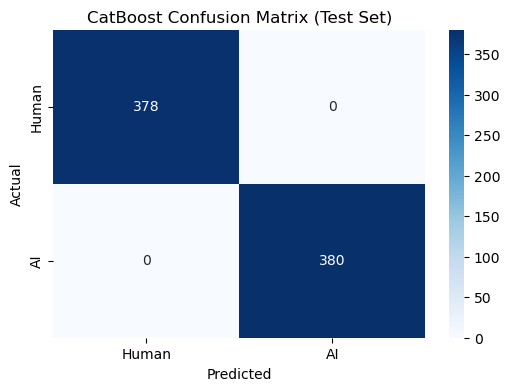


--- CatBoost Results ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00       378
      AI (1)       1.00      1.00      1.00       380

    accuracy                           1.00       758
   macro avg       1.00      1.00      1.00       758
weighted avg       1.00      1.00      1.00       758



In [71]:
# predictions and evaluation
catboost_pred = catboost_model.predict(X_test_df)

# confusion matrix
cm = confusion_matrix(y_test, catboost_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human", "AI"], 
            yticklabels=["Human", "AI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Confusion Matrix (Test Set)")
plt.show()

# compute and evaluate SVM results
print("\n--- CatBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test, catboost_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, catboost_pred, target_names=['Human (0)', 'AI (1)']))

In [72]:
# apply deep cleaning
X_train_svm = X_train_base.apply(deep_clean_text)
X_test_svm = X_test_base.apply(deep_clean_text)

# train TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# fit only on training data, then transform both
X_train_tfidf = tfidf.fit_transform(X_train_svm)
X_test_tfidf = tfidf.transform(X_test_svm)

In [73]:
# initialize the SVM with linear kernel
svm_model = SVC(kernel='linear', random_state=1)

# train the model using the TF-IDF vectorized training data
svm_model.fit(X_train_tfidf, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


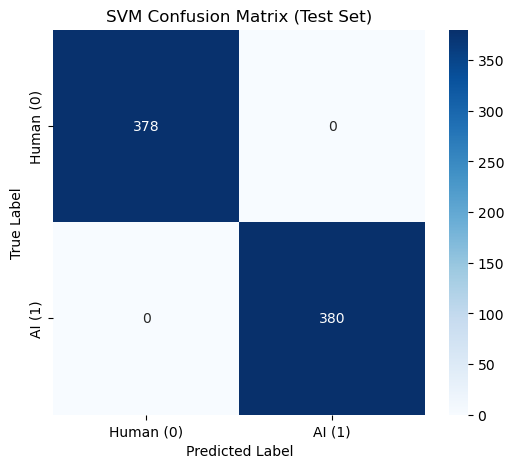


--- SVM Results ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00       378
      AI (1)       1.00      1.00      1.00       380

    accuracy                           1.00       758
   macro avg       1.00      1.00      1.00       758
weighted avg       1.00      1.00      1.00       758



In [74]:
# predict on the test set
svm_preds = svm_model.predict(X_test_tfidf)

# display confusion matrix
conf_matrix = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human (0)", "AI (1)"], 
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# compute and evaluate SVM results
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_preds, target_names=['Human (0)', 'AI (1)']))

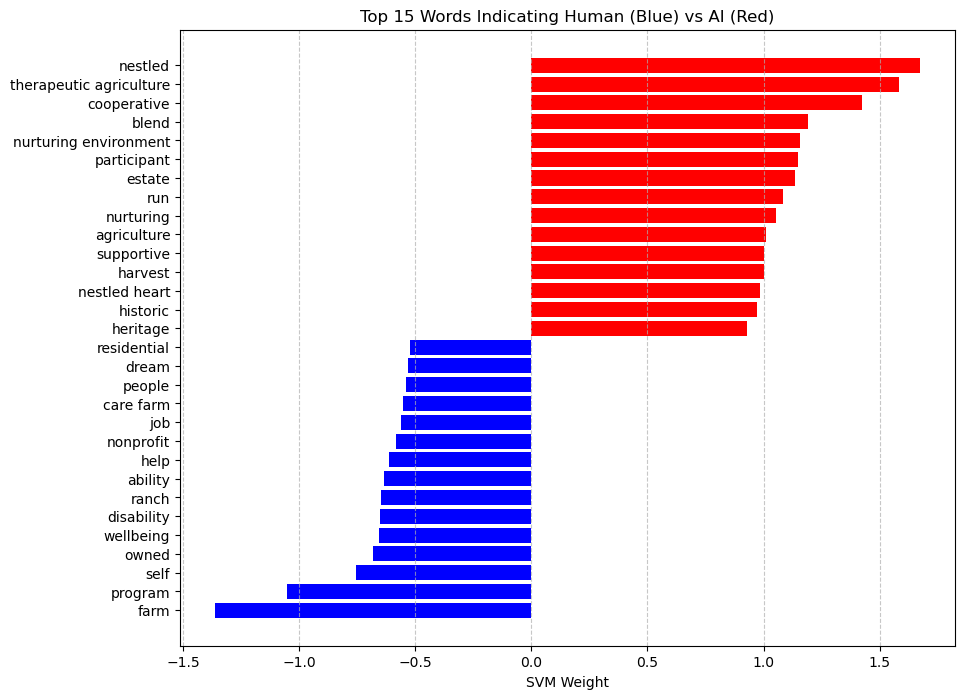

In [75]:
# Extract the coefficients and feature names
coefficients = svm_model.coef_.toarray()[0]
feature_names = tfidf.get_feature_names_out()

# Create a DataFrame of words and their weights
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients
})

# Sort by weight
# Negative weights = Human (Class 0), Positive weights = AI (Class 1)
feature_importance = feature_importance.sort_values(by='Weight', ascending=True)

# Get top 15 words for Human and top 15 words for AI
top_human_words = feature_importance.head(15)
top_ai_words = feature_importance.tail(15)

# Combine them for the plot
top_features_combined = pd.concat([top_human_words, top_ai_words])

plt.figure(figsize=(10, 8))
# Color human words blue and AI words red
colors = ['blue' if x < 0 else 'red' for x in top_features_combined['Weight']]
plt.barh(top_features_combined['Feature'], top_features_combined['Weight'], color=colors)

plt.xlabel('SVM Weight')
plt.title('Top 15 Words Indicating Human (Blue) vs AI (Red)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

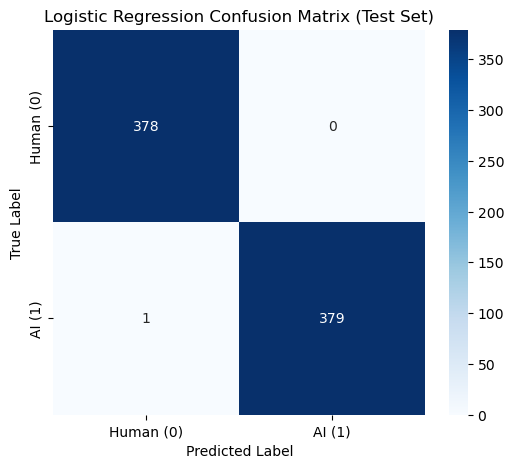


--- Logistic Regression Results ---
Accuracy: 0.9987

Classification Report:
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00       378
      AI (1)       1.00      1.00      1.00       380

    accuracy                           1.00       758
   macro avg       1.00      1.00      1.00       758
weighted avg       1.00      1.00      1.00       758



In [76]:
# Logistic Regression on TF-IDF features
lr_model = LogisticRegression(max_iter=1000, random_state=1)
lr_model.fit(X_train_tfidf, y_train)

# predict on test set
lr_preds = lr_model.predict(X_test_tfidf)

# confusion matrix
lr_cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human (0)", "AI (1)"],
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix (Test Set)")
plt.show()

# classification report
print("\n--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Human (0)', 'AI (1)']))

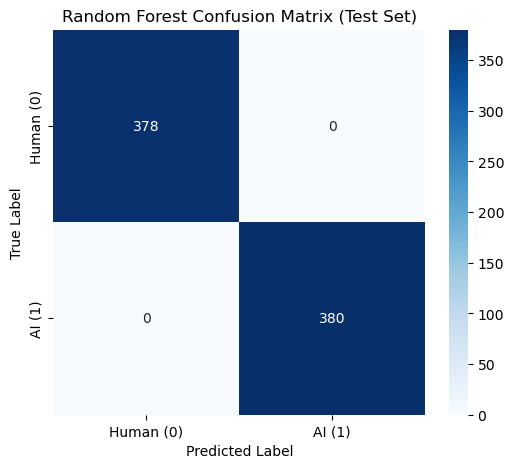


--- Random Forest Results ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00       378
      AI (1)       1.00      1.00      1.00       380

    accuracy                           1.00       758
   macro avg       1.00      1.00      1.00       758
weighted avg       1.00      1.00      1.00       758



In [77]:
# Random Forest on TF-IDF features
rf_model = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# predict on test set
rf_preds = rf_model.predict(X_test_tfidf)

# confusion matrix
rf_cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human (0)", "AI (1)"],
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix (Test Set)")
plt.show()

# classification report
print("\n--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Human (0)', 'AI (1)']))

In [78]:
# Save trained models and TF-IDF vectorizer for Streamlit app
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save TF-IDF vectorizer (shared by SVM, LR, RF)
joblib.dump(tfidf, 'models/tfidf_jobs.pkl')

# Save models
joblib.dump(svm_model, 'models/svm_jobs.pkl')
joblib.dump(lr_model, 'models/lr_jobs.pkl')
joblib.dump(rf_model, 'models/rf_jobs.pkl')
catboost_model.save_model('models/catboost_jobs.cbm')

print('All job models saved to models/ directory')

All job models saved to models/ directory


In [79]:
def light_clean_text(text):
    # remove HTML tags if present
    text = re.sub(r'<.*?>', '', text)

    # remove extra whitespaces/lines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [80]:
# apply light cleaning
X_train_transformer = X_train_base.apply(light_clean_text).tolist()
X_test_transformer = X_test_base.apply(light_clean_text).tolist()

# create validation set (from the training data)
X_train_transformer, X_val_transformer, y_train_np, y_val_np = train_test_split(
    X_train_transformer, 
    y_train, 
    test_size=0.20,
    random_state=1, 
    stratify=y_train
)

# convert final test labels to numpy array for consistency
y_test_np = np.array(y_test)

In [81]:
# define the pre-trained model
preset = "bert_tiny_en_uncased"

# create preprocessor
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    preset=preset,
    sequence_length=128
)

# create classifier
classifier = keras_nlp.models.BertClassifier.from_preset(
    preset=preset,
    preprocessor=preprocessor,
    num_classes=2
)

# compile classifier
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    metrics=["accuracy"]
)

# display classifier summary
classifier.summary()

TypeError: <class 'keras_nlp.src.models.bert.bert_tokenizer.BertTokenizer'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras_nlp.src.models.bert.bert_tokenizer', 'class_name': 'BertTokenizer', 'config': {'name': 'bert_tokenizer', 'trainable': True, 'dtype': 'int32', 'vocabulary': None, 'sequence_length': None, 'lowercase': True, 'strip_accents': False, 'split': True, 'suffix_indicator': '##', 'oov_token': '[UNK]'}, 'registered_name': 'keras_nlp>BertTokenizer', 'assets': ['assets/tokenizer/vocabulary.txt'], 'weights': None}.

Exception encountered: Error when deserializing class 'BertTokenizer' using config={'name': 'bert_tokenizer', 'trainable': True, 'dtype': 'int32', 'vocabulary': None, 'sequence_length': None, 'lowercase': True, 'strip_accents': False, 'split': True, 'suffix_indicator': '##', 'oov_token': '[UNK]'}.

Exception encountered: BertTokenizer requires the `tensorflow-text` package. Please install with `pip install tensorflow-text`.

In [ ]:
# define callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=3, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

# fine-tune the BERT model 
history = classifier.fit(
    x=X_train_transformer,
    y=y_train_np,
    validation_data=(X_val_transformer, y_val_np),
    epochs=10,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], linestyle='-', label='Training Loss')
plt.plot(history.history['val_loss'], linestyle='-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history.history['accuracy'], linestyle='-', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linestyle='-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training/Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# evaluate the fine-tuned BERT model
bert_test_loss, bert_test_accuracy = classifier.evaluate(
    x=X_test_transformer, 
    y=y_test_np, 
    verbose=1
)

# get predictions (these will be logits because from_logits=True)
test_preds = classifier.predict(X_test_transformer)

# convert logits to binary labels using argmax
pred_labels = np.argmax(test_preds, axis=1)

# compute confusion matrix
conf_matrix = confusion_matrix(y_test_np, pred_labels)

# display confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human (0)", "AI (1)"], 
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERT Confusion Matrix (Test Set)")
plt.show()

# Print results
print("\n--- BERT Results ---")
print(f"BERT Test Loss: {bert_test_loss:.4f}")
print(f"BERT Test Accuracy: {bert_test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_np, pred_labels, target_names=["Human (0)", "AI (1)"]))

In [ ]:
# --- A. CatBoost Learning Curve ---
evals_result = catboost_model.get_evals_result()

plt.figure(figsize=(8, 5))
plt.plot(evals_result['learn']['Logloss'], label='Training Logloss')
plt.plot(evals_result['validation']['Logloss'], label='Validation Logloss')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.title('CatBoost Learning Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- B. CatBoost SHAP Summary Plot ---
print("Calculating SHAP values...")
# Create a Pool object required by SHAP for text features
test_pool = Pool(X_test_df, text_features=['full_text'])

# Initialize SHAP explainer and calculate values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(test_pool)

# Plot summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("CatBoost SHAP Summary Plot")
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# --- A. PCA Dimensionality Reduction ---
print("Running PCA on TF-IDF vectors...")
pca = PCA(n_components=2, random_state=42)
# Convert sparse TF-IDF matrix to dense for PCA
X_test_dense = X_test_tfidf.toarray()
X_test_pca = pca.fit_transform(X_test_dense)

# --- B. Train a 2D SVM for Visualization ---
svm_2d = SVC(kernel='linear', random_state=1)
svm_2d.fit(X_test_pca, y_test)

# --- C. Plotting the Decision Boundary ---
plt.figure(figsize=(10, 8))

# Create a mesh grid
x_min, x_max = X_test_pca[:, 0].min() - 0.1, X_test_pca[:, 0].max() + 0.1
y_min, y_max = X_test_pca[:, 1].min() - 0.1, X_test_pca[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Predict across the grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw the boundary and background regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

# Scatter the actual test data
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, 
                      cmap="coolwarm", edgecolors='k', alpha=0.7)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('SVM 2D PCA Scatter & Decision Boundary')

# Add legend
legend_elements = scatter.legend_elements()[0]
plt.legend(handles=legend_elements, labels=["Human (0)", "AI (1)"])
plt.show()

In [ ]:
from sklearn.manifold import TSNE
import tensorflow as tf

print("Extracting BERT embeddings...")
# Run the raw text through the preprocessor
processed_inputs = preprocessor(X_test_transformer)

# Pass the processed inputs through the BERT backbone to get embeddings
backbone_outputs = classifier.backbone.predict(processed_inputs)

# Extract the CLS token representation (pooled_output)
embeddings = backbone_outputs['pooled_output']

print("Running t-SNE to compress embeddings to 2D...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plotting the Latent Space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=y_test_np, 
                      cmap='coolwarm', edgecolors='k', alpha=0.7)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('BERT Latent Space Clustering (t-SNE)')

legend_elements = scatter.legend_elements()[0]
plt.legend(handles=legend_elements, labels=["Human (0)", "AI (1)"])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()